In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk
import sys

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)

seq_length = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]

In [3]:
from src.utils import ContrastSamples

In [4]:
(
    base_pixel,
    base_mppc,
    contrast_pixel_signal,
    contrast_mppc_signal,
    contrast_pixel_background,
    contrast_mppc_background,
) = ContrastSamples(
    bg_pixel_spacetime,
    sig_only_pixel_spacetime,
    bg_mppc_spacetime,
    sig_only_mppc_spacetime,
    num_samples=200000,
    padding_value=-1,
)

Used 68245/77593 background events.
Used 75839/87573 signal events.


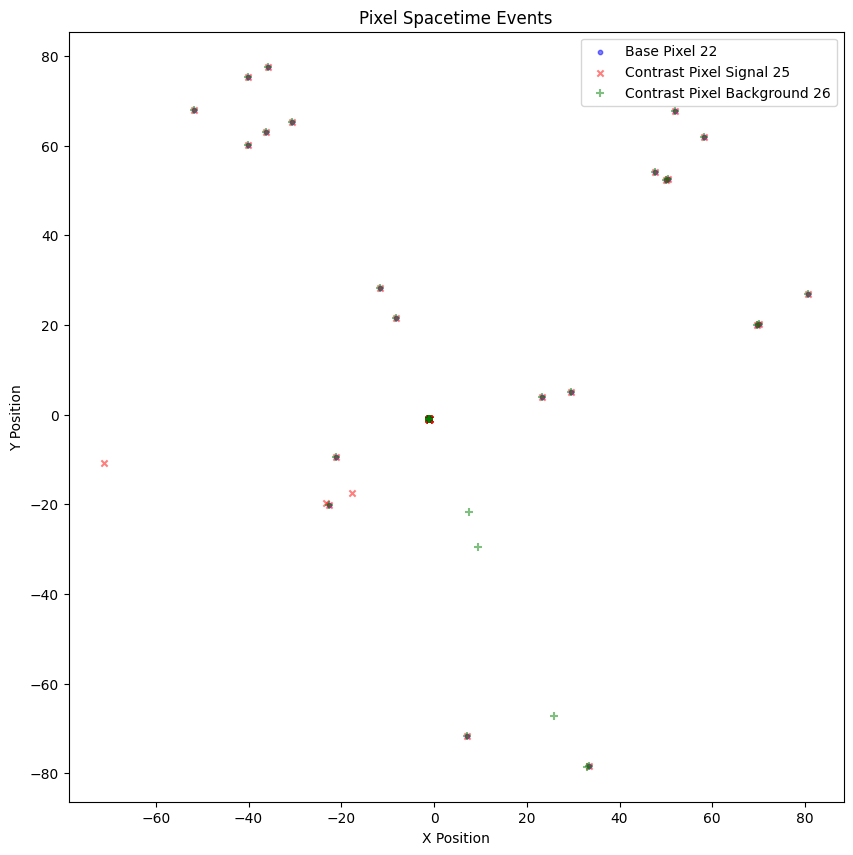

In [5]:
event_id = 4
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    base_pixel[event_id, :, 0],
    base_pixel[event_id, :, 1],
    c="blue",
    label=f"Base Pixel {np.sum(base_pixel[event_id, :, 0] != -1)}",
    s=10,
    alpha=0.5,
    marker="o",
)
ax.scatter(
    contrast_pixel_signal[event_id, :, 0],
    contrast_pixel_signal[event_id, :, 1],
    c="red",
    label=f"Contrast Pixel Signal {np.sum(contrast_pixel_signal[event_id, :, 0] != -1)}",
    s=20,
    alpha=0.5,
    marker="x",
)
ax.scatter(
    contrast_pixel_background[event_id, :, 0],
    contrast_pixel_background[event_id, :, 1],
    c="green",
    label=f"Contrast Pixel Background {np.sum(contrast_pixel_background[event_id, :, 0] != -1)}",
    s=30,
    alpha=0.5,
    marker="+",
)
ax.set_title("Pixel Spacetime Events")
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.legend()

In [6]:
from src.model.components import (
    SelfAttentionStack,
    SelfAttentionBlock,
    CrossAttentionBlock,
    PoolingAttentionBlock,
    MultiHeadAttentionBlock,
    GenerateMask,
    MLP,
)

feature_dim = 16
num_heads = 8
latent_dim = 8
num_seeds = 1
dropout_rate = 0

pixel_input = keras.Input(shape=(seq_length, input_dim), name="pixel_input")
mppc_input = keras.Input(shape=(seq_length, input_dim), name="mppc_input")

pixel_mask = GenerateMask(name="mask")(pixel_input)
pixel_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="pixel_embedding",
    dropout_rate=dropout_rate,
)(pixel_input)

pixel_self_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 2,
    name="pixel_self_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)(pixel_embedding , mask = pixel_mask)
mppc_mask = GenerateMask(name="mppc_mask")(mppc_input)
mppc_embedding = MLP(
    num_layers=4,
    output_dim=feature_dim,
    activation="relu",
    name="mppc_embedding",
    dropout_rate=dropout_rate,
)(mppc_input)
mppc_self_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size = 2,
    name="mppc_self_attention",
    dropout_rate=dropout_rate,
    pre_ln=True,
)(mppc_embedding , mask = mppc_mask)


pixel_attend_mppc = MultiHeadAttentionBlock(
    num_heads=num_heads,
    key_dim=feature_dim,
    name="pixel_attend_mppc",
    dropout_rate=dropout_rate,
)(pixel_embedding, mppc_embedding, query_mask=pixel_mask, value_mask=mppc_mask)

pixel_attend_self = SelfAttentionBlock(
    num_heads=num_heads,
    key_dim=feature_dim,
    name="pixel_attend_self",
    dropout_rate=dropout_rate,
)(pixel_attend_mppc, mask=pixel_mask)


mppc_attend_pixel = MultiHeadAttentionBlock(
    num_heads=num_heads,
    key_dim=feature_dim,
    name="mppc_attend_pixel",
    dropout_rate=dropout_rate,
)(mppc_embedding, pixel_attend_self, query_mask=mppc_mask, value_mask=pixel_mask)


pixel_pooling = PoolingAttentionBlock(
    num_seeds = num_seeds,
    key_dim=feature_dim,
    name="pooling_attention",
    dropout_rate=dropout_rate,
)(pixel_attend_mppc, mask=pixel_mask)

mppc_pooling = PoolingAttentionBlock(
    num_seeds = num_seeds,
    key_dim=feature_dim,
    name="mppc_pooling_attention",
    dropout_rate=dropout_rate,
)(mppc_attend_pixel, mask=mppc_mask)


latent_space = keras.layers.Concatenate(name="latent_space")([pixel_pooling, mppc_pooling])
latent_space = keras.layers.Flatten(name="flatten")(latent_space)
output = MLP(
    num_layers=4,
    output_dim=latent_dim,
    activation="linear",
    name="output",
    dropout_rate=dropout_rate,
)(latent_space)

transformer_embedding = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=output,
    name="ClassificationModel",
)

/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'pixel_self_attention' (of type SelfAttentionStack) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'mppc_self_attention' (of type SelfAttentionStack) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'self_attention_block_4' (of type SelfAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore dest

In [7]:
transformer_embedding.summary()

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_input          │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_embedding     │ (None, 128, 16)   │        364 │ pixel_input[0][0] │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_embedding      │ (None, 128, 16)   │        364 │ mppc_input[0][0]  │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (GenerateMask) │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_mask           │ (None, 128, 1)    │          0 │ mppc_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attend_mppc   │ (None, 128, 16)   │      1,168 │ pixel_embedding[… │
│ (MultiHeadAttentio… │                   │            │ mppc_embedding[0… │
│                     │                   │            │ mask[0][0],       │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_blo… │ (None, 128, 16)   │      1,136 │ pixel_attend_mpp… │
│ (SelfAttentionBloc… │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attend_pixel   │ (None, 128, 16)   │      1,168 │ mppc_embedding[0… │
│ (MultiHeadAttentio… │                   │            │ self_attention_b… │
│                     │                   │            │ mppc_mask[0][0],  │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_attention   │ (None, 1, 16)     │      2,256 │ pixel_attend_mpp… │
│ (PoolingAttentionB… │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_pooling_atten… │ (None, 1, 16)     │      2,256 │ mppc_attend_pixe… │
│ (PoolingAttentionB… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 1, 32)     │          0 │ pooling_attentio… │
│ (Concatenate)       │                   │            │ mppc_pooling_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (MLP)        │ (None, 8)         │      1,377 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,089 (39.41 KB)

 Trainable params: 10,089 (39.41 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from src.model.wrapper import make_siamese_encoder

siamese_model = make_siamese_encoder(
    transformer_embedding,
    num_contrastive_views=3,
)

In [9]:
from src.training import TripletLoss, TripletLossWithRegularization, VarianceCovarianceLoss

In [10]:
siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=TripletLossWithRegularization(VarianceCovarianceLoss())
)

In [11]:
from sklearn.model_selection import train_test_split

(
    base_pixel_train,
    base_pixel_val,
    base_mppc_train,
    base_mppc_val,
    contrast_pixel_signal_train,
    contrast_pixel_signal_val,
    contrast_mppc_signal_train,
    contrast_mppc_signal_val,
    contrast_pixel_background_train,
    contrast_pixel_background_val,
    contrast_mppc_background_train,
    contrast_mppc_background_val,
) = train_test_split(
    base_pixel,
    base_mppc,
    contrast_pixel_signal,
    contrast_mppc_signal,
    contrast_pixel_background,
    contrast_mppc_background,
    test_size=0.2,
    random_state=42,
)

In [ ]:
siamese_model.fit(
    x=[
        base_pixel_train,
        base_mppc_train,
        contrast_pixel_background_train,
        contrast_mppc_background_train,
        contrast_pixel_signal_train,
        contrast_mppc_signal_train,
    ],
    y=np.zeros(contrast_mppc_signal.shape[0]),  # Dummy labels
    validation_split=0.2,
    epochs=10,
    batch_size=128,
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1213s 1s/step - loss: 0.9497 - val_loss: 0.6916
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1116s 1s/step - loss: 0.6206 - val_loss: 0.5428
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - loss: 0.5527

In [ ]:
from sklearn.model_selection import train_test_split

bg_pixel_train, bg_pixel_test, big_mppc_train, bg_mppc_test = train_test_split(
    bg_pixel_spacetime, bg_mppc_spacetime, test_size=0.2, random_state=42
)
sig_pixel_train, sig_pixel_test, sig_mppc_train, sig_mppc_test = train_test_split(
    sig_pixel_spacetime, sig_mppc_spacetime, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent = transformer_embedding.predict([base_pixel_train, base_mppc_train])
pca.fit(latent)

In [ ]:
signal_latent = transformer_embedding.predict([contrast_pixel_signal_val, contrast_mppc_signal_val])
background_latent = transformer_embedding.predict([base_pixel_val, base_mppc_val])
transformed_signal = pca.transform(signal_latent)
transformed_background = pca.transform(background_latent)
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    transformed_signal[:, 0],
    transformed_signal[:, 1],
    label="Signal",
    alpha=0.5,
    s=1,
)
ax.scatter(
    transformed_background[:, 0],
    transformed_background[:, 1],
    label="Background",
    alpha=0.5,
    s=1,
)
ax.set_title("PCA of Latent Space")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.show()

In [ ]:
from src.evaluation import plot_latent_variable_distributions

In [ ]:
plot_latent_variable_distributions(signal_latent, background_latent)